In [1]:
#Evaluation-of-Perceptual-Hash-Algorithms
#Import Libs

import os
import cv2
import hashlib
import imagehash
import pandas as pd
import matplotlib as mpl

from PIL import Image
from scipy.spatial import *
from matplotlib import pyplot as plot

In [2]:
#Download da Biblioteca para Avaliar algoritmos de Hash Perceptual
#https://pypi.org/project/ImageHash/

In [3]:
#Warning Fix
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
#Path & Database Definition
path = 'D:/Google Drive/Github/Evaluation-of-Perceptual-Hash-Algorithms/ImageDatabase/'
database = "MountainDatabase"

In [5]:
#Path Update and Extension File Type
path = path + database + "/"
ext = ".jpg"

In [6]:
#Altered Image Definition
image_name = str(input("Altered Image Name: "));
image_name = image_name + ext

Altered Image Name: Alternative (17)


In [7]:
#Import Original and Altered Image
original = cv2.imread(path + 'original.jpg')
alterada = cv2.imread(path + image_name)

In [8]:
#Ordering RGB Layers
original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)
alterada = cv2.cvtColor(alterada,cv2.COLOR_BGR2RGB)

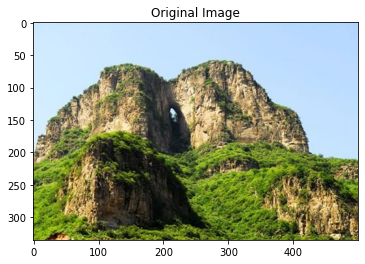

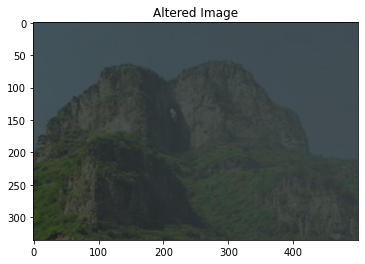

In [9]:
#Original Image
plot.imshow(original,cmap='gray')
plot.title('Original Image')
plot.show()

#Altered Image
plot.imshow(alterada,cmap='gray')
plot.title('Altered Image')
plot.show()

In [10]:
#Create a copy of Altered Image to use the Perceptual Hashing
alterada = cv2.cvtColor(alterada,cv2.COLOR_BGR2RGB)
cv2.imwrite(path + 'img2.jpg', alterada);

<b> Hamming Distance

In [11]:
#Hamming Distance Function
def hamming(hash1,hash2):
    L = len(hash1)
    distance = 0
    
    for i in range(L):
        if hash1[i] != hash2[i]:
            distance += 1

    return(str(distance))

<b> Conventional Hash Experiment </b>
- MD5
- SHA1
- SHA256

In [12]:
#Import of binary files
file1 = path + 'original.jpg'
file2 = path + image_name

In [13]:
#File Reading
with open(file1, 'rb') as f1:
    data1 = f1.read()
with open(file2, 'rb') as f2:
    data2 = f2.read()

In [14]:
#Hash Md5, Sha1 and Sha256 Calc
md5_original = str(hashlib.md5(data1).hexdigest())
md5_alterada = str(hashlib.md5(data2).hexdigest())

sha1_original = str(hashlib.sha1(data1).hexdigest())
sha1_alterada = str(hashlib.sha1(data2).hexdigest())

sha256_original = str(hashlib.sha256(data1).hexdigest())
sha256_alterada = str(hashlib.sha256(data2).hexdigest())

<b> Perceptual Hash Experiment</b>
- Average hashing
- Perceptual hashing
- Difference hashing
- Wavelet hashing
- HSV color hashing (ColorHash)
- Crop-resistant hashing

In [15]:
#Average Hashing
ahash1 = str(imagehash.average_hash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
ahash2 = str(imagehash.average_hash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
ahash_dist = hamming(ahash1,ahash2)

In [16]:
#Perceptual Hashing
phash1 = str(imagehash.phash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
phash2 = str(imagehash.phash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
phash_dist = hamming(phash1,phash2)

In [17]:
#Difference Hashing
dhash1 = str(imagehash.dhash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
dhash2 = str(imagehash.dhash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
dhash_dist = hamming(dhash1,dhash2)

In [18]:
#HSV Color Hashing
hsvhash1 = str(imagehash.colorhash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
hsvhash2 = str(imagehash.colorhash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
hsvhash_dist = hamming(hsvhash1,hsvhash2)

In [19]:
#Wavelet Hashing
whash1 = str(imagehash.whash(Image.open('ImageDatabase/MountainDatabase/original.jpg')))
whash2 = str(imagehash.whash(Image.open('ImageDatabase/MountainDatabase/img2.jpg')))
whash_dist = hamming(whash1,whash2)

In [20]:
#Crop-Resistant Hashing
crhash1 = imagehash.crop_resistant_hash(Image.open('ImageDatabase/MountainDatabase/original.jpg'))
crhash2 = imagehash.crop_resistant_hash(Image.open('ImageDatabase/MountainDatabase/img2.jpg'))

ArrayImage01 = str(crhash1).split(',')
ArrayImage02 = str(crhash2).split(',')

if len(ArrayImage01) <= len(ArrayImage02):
    menor = len(ArrayImage01)
    maior = len(ArrayImage02)
    
    total = maior - menor
    for i in range(total):
        ArrayImage01.append('################')
    
elif len(ArrayImage02) < len(ArrayImage01):
    menor = len(ArrayImage02)
    maior = len(ArrayImage01)
    
    total = maior - menor
    for i in range(total):
        ArrayImage02.append('################')

In [21]:
#Function to show the Results about Crop-Resistance Hashing Hamming Distance
total = 0
for i in range(maior):

    
    distance = 0
    string1 = ArrayImage01[i]
    string2 = ArrayImage02[i]
    
    for n in range(len(string1)):        
        if string1[n] != string2[n]:
            distance += 1
    
    total = total + distance
media = total / maior

print("Total of Reductions: " + str(maior) + " with the Original File")
print("Sum of Hamming Distances: " + str(total))
print("Mean Hamming Distances: " + str(media))

Total of Reductions: 6 with the Original File
Sum of Hamming Distances: 91
Mean Hamming Distances: 15.166666666666666


# Results

In this steps, All the results are inputed in the Dataframes. 
The Dataframes are:
- df0: Image and Database Names
- df1: Conventional Hash
- df2: Perceptual Hash
- df3: Crop-Resistance Hash
- df4: All Hamming Distance Values

In [22]:
#Ajust the Dataframe to Show all Information Value
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [23]:
#Create Dataframes to Show All results
df0 = pd.DataFrame(columns=('ImageName', 'Database'))
df1 = pd.DataFrame(columns=('MD5', 'SHA1', 'SHA256'))
df2 = pd.DataFrame(columns=('Ahash', 'Phash', 'Dhash', 'Whash', 'Hsv-Chash'))
df3 = pd.DataFrame()

for i in range(maior):
    colname = "CPR Hash 0" + str(i + 1)
    df3[colname] = colname
    
df4 = pd.DataFrame(columns=('Hamming Distance', 'Ahash', 'Phash', 'Dhash', 'Whash', 'Hsv-Chash', 'CPRhash'))

In [24]:
#Attach the Values - Image Names
values_hash1 = {'ImageName': "Original", 'Database': database};
values_hash2 = {'ImageName': image_name, 'Database': database};

df0 = df0.append(values_hash1, ignore_index = True);
df0 = df0.append(values_hash2, ignore_index = True);

In [25]:
#Attach the Values - Conventional Hash
values_hash1 = {'MD5': md5_original, 'SHA1': sha1_original, 'SHA256': sha256_original};
values_hash2 = {'MD5': md5_alterada, 'SHA1': sha1_alterada, 'SHA256': sha256_alterada};

df1 = df1.append(values_hash1, ignore_index = True);
df1 = df1.append(values_hash2, ignore_index = True);

In [26]:
#Attach the Values - Perceptual Hash
values_hash1 = {'Ahash': ahash1, 'Phash': phash1, 'Dhash': dhash1, 'Whash': whash1, 'Hsv-Chash': hsvhash1};
values_hash2 = {'Ahash': ahash2, 'Phash': phash2, 'Dhash': dhash2, 'Whash': whash2, 'Hsv-Chash': hsvhash2};

df2 = df2.append(values_hash1, ignore_index = True);
df2 = df2.append(values_hash2, ignore_index = True);

In [27]:
#Attach the Values - Crop-Resistance Hash
for i in range(maior):
    colname = "CPR Hash 0" + str(i + 1)
    df3.at[0, colname] = ArrayImage01[i]
    df3.at[1, colname] = ArrayImage02[i]

In [28]:
#Attach the Values - Hamming Distance
values_hash1 = {'Hamming Distance': 'Original','Ahash': 0, 'Phash': 0, 'Dhash': 0, 'Whash': 0, 'Hsv-Chash': 0, 'CPRhash': 0};
values_hash2 = {'Hamming Distance': image_name,'Ahash': ahash_dist, 'Phash': phash_dist, 'Dhash': dhash_dist, 'Whash': whash_dist, 'Hsv-Chash': hsvhash_dist, 'CPRhash': media};

df4 = df4.append(values_hash1, ignore_index = True);
df4 = df4.append(values_hash2, ignore_index = True);

In [29]:
df0

,ImageName,Database
0,Original,MountainDatabase
1,Alternative (17).jpg,MountainDatabase


In [30]:
df1

,MD5,SHA1,SHA256
0,ee07bb8f2c127818b7937d916625cdec,b568dc0fa979fb62c40abdc34461374590ba8647,2f5ef85537cff9955de11644329785588d41699f302f6c0cbd2cdf716d892118
1,907f05f2ca68b71736fa841138dbab07,c9d254f53b6ace068665f1d1028b3ed67b66e88d,662b29a7ae7fe0c2e051628d020905d0faa54f05cfa1c4036801fe02219db3d7


In [31]:
df2

,Ahash,Phash,Dhash,Whash,Hsv-Chash
0,ffffc7cb01000000,b9c4c65a8bd15c3c,402416531b191a1f,ffffd7eb8b000000,03640002000
1,ffffcfcf0b000200,b9e6c48283f17c3c,002416531b391e3f,ffffc7cf0f000200,071c0000000


In [32]:
df3

,CPR Hash 01,CPR Hash 02,CPR Hash 03,CPR Hash 04,CPR Hash 05,CPR Hash 06
0,00442616175b3b19,a5e7b2edccfcfade,c7d7f13858c4ee02,2246cc2d3a56cd91,849c4c481e9d2636,2616531b3b181e1b
1,002416531b391e3f,################,################,################,################,################


In [33]:
df4

,Hamming Distance,Ahash,Phash,Dhash,Whash,Hsv-Chash,CPRhash
0,Original,0,0,0,0,0,0
1,Alternative (17).jpg,4,8,4,6,4,15.166667


Create a task to export all the DataFrames together.<br>
To this, we use the function join with all the DataFrames and write the file with .csv format

In [34]:
#Concat all the Dataframes
df = pd.concat([df0, df1, df2, df3, df4], axis = 1)

In [35]:
#Export Dataframe to .csv File
df.to_csv('Export.csv', encoding='utf-8', index=False)